In [2]:
#Importación de librerías generales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [3]:
#Importación de librerías ML
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [4]:
#Ruta
os.chdir(r"C:\Users\Nefi\OneDrive\Documentos\09-EBAC\EBACMX-DATA-ANALYST\Referencias")

#Cargar datos
df = pd.read_csv("sales_consolidado.csv")

#Visualización inicial
df.head()

,ID_SALES,WEEK,ITEM_CODE,REGION,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,ID_ITEM,ITEM,MANUFACTURER,...,FORMAT,ATTR1,ATTR2,ATTR3,ID_CATEGORY,CATEGORY_y,YEAR,MONTH,WEEK_NUMBER,DATE
0,1,34-22,7501058792808BP2,TOTAL AUTOS AREA 5,0.006,0.139,1.000,313.0,7501058792808BP2,RECKITT,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1.0,FABRIC TREATMENT and SANIT,2022,8,34,2022-08-28
1,2,34-22,7501060000000,TOTAL AUTOS AREA 5,0.487,116.519,2.916,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2022,8,34,2022-08-28
2,3,34-22,7702630000000,TOTAL AUTOS AREA 5,1.391,68.453,5.171,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2022,8,34,2022-08-28
3,4,34-22,7501060000000,TOTAL AUTOS AREA 5,0.022,1.481,1.833,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2022,8,34,2022-08-28
4,5,34-22,7501060000000,TOTAL AUTOS AREA 5,2.037,182.839,5.375,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2022,8,34,2022-08-28


In [5]:
#EDA-Información general
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122002 entries, 0 to 122001
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ID_SALES                     122002 non-null  int64  
 1   WEEK                         122002 non-null  object 
 2   ITEM_CODE                    122002 non-null  object 
 3   REGION                       122002 non-null  object 
 4   TOTAL_UNIT_SALES             122002 non-null  float64
 5   TOTAL_VALUE_SALES            122002 non-null  float64
 6   TOTAL_UNIT_AVG_WEEKLY_SALES  122002 non-null  float64
 7   ID_ITEM                      9193 non-null    float64
 8   ITEM                         9193 non-null    object 
 9   MANUFACTURER                 9193 non-null    object 
 10  BRAND                        9193 non-null    object 
 11  ITEM_DESCRIPTION             9193 non-null    object 
 12  CATEGORY_x                   9193 non-null    float64
 13 

,ID_SALES,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,ID_ITEM,CATEGORY_x,ID_CATEGORY,YEAR,MONTH,WEEK_NUMBER
count,122002.000000,122002.000000,122002.000000,122002.000000,9193.000000,9193.0,9193.0,122002.000000,122002.000000,122002.000000
mean,61001.500000,3.211097,90.513761,10.099904,358.698684,1.0,1.0,2022.334396,5.531729,22.141194
std,35219.088108,14.496009,350.236505,22.650142,79.881153,0.0,0.0,0.471781,3.214612,14.134943
min,1.000000,0.000000,0.001000,0.042000,159.000000,1.0,1.0,2022.000000,1.000000,1.000000
25%,30501.250000,0.063000,2.662000,2.316000,313.000000,1.0,1.0,2022.000000,3.000000,10.000000
50%,61001.500000,0.367000,16.812000,3.993500,321.000000,1.0,1.0,2022.000000,5.000000,20.000000
75%,91501.750000,1.520000,62.961500,8.898000,461.000000,1.0,1.0,2023.000000,8.000000,32.000000
max,122002.000000,504.681000,12236.759000,794.000000,505.000000,1.0,1.0,2023.000000,12.000000,52.000000


In [6]:
#EDA-Información particular de interés
#Verificar columnas
print(df.columns)

#Ver valores únicos clave
print("Categorías únicas:", df['CATEGORY_x'].unique())
print("Productos únicos:", df['ITEM'].nunique())

#Revisar rango de fechas
print("Fecha mínima:", df['DATE'].min())
print("Fecha máxima:", df['DATE'].max())

Index(['ID_SALES', 'WEEK', 'ITEM_CODE', 'REGION', 'TOTAL_UNIT_SALES',
       'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES', 'ID_ITEM', 'ITEM',
       'MANUFACTURER', 'BRAND', 'ITEM_DESCRIPTION', 'CATEGORY_x', 'FORMAT',
       'ATTR1', 'ATTR2', 'ATTR3', 'ID_CATEGORY', 'CATEGORY_y', 'YEAR', 'MONTH',
       'WEEK_NUMBER', 'DATE'],
      dtype='object')
Categorías únicas: [ 1. nan]
Productos únicos: 35
Fecha mínima: 2022-01-09
Fecha máxima: 2023-07-17


In [7]:
#Preparación y limpieza de datos
#Filtrar solo CATEGORY_x = 1 para manupulación de datos de interés
df = df[df['CATEGORY_x'] == 1].copy()

#Confirmar tamaño
print("Dimensión después del filtro:", df.shape)

Dimensión después del filtro: (9193, 23)


In [8]:
#Convertir fecha a datetime
df['DATE'] = pd.to_datetime(df['DATE'])

#Ordenar por fecha
df = df.sort_values(by='DATE')

In [9]:
# Validación final
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 9193 entries, 93541 to 86139
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID_SALES                     9193 non-null   int64         
 1   WEEK                         9193 non-null   object        
 2   ITEM_CODE                    9193 non-null   object        
 3   REGION                       9193 non-null   object        
 4   TOTAL_UNIT_SALES             9193 non-null   float64       
 5   TOTAL_VALUE_SALES            9193 non-null   float64       
 6   TOTAL_UNIT_AVG_WEEKLY_SALES  9193 non-null   float64       
 7   ID_ITEM                      9193 non-null   float64       
 8   ITEM                         9193 non-null   object        
 9   MANUFACTURER                 9193 non-null   object        
 10  BRAND                        9193 non-null   object        
 11  ITEM_DESCRIPTION             9193 non-null 

,ID_SALES,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,ID_ITEM,CATEGORY_x,ID_CATEGORY,YEAR,MONTH,WEEK_NUMBER,DATE
count,9193.000000,9193.000000,9193.000000,9193.000000,9193.000000,9193.0,9193.0,9193.000000,9193.000000,9193.000000,9193
mean,59937.846296,0.440375,8.309725,4.984865,358.698684,1.0,1.0,2022.290112,5.347873,21.266290,2022-09-13 18:07:05.280104448
min,1.000000,0.001000,0.001000,0.850000,159.000000,1.0,1.0,2022.000000,1.000000,1.000000,2022-01-09 00:00:00
25%,29636.000000,0.007000,0.221000,1.902000,313.000000,1.0,1.0,2022.000000,3.000000,10.000000,2022-04-24 00:00:00
50%,59282.000000,0.044000,1.310000,3.000000,321.000000,1.0,1.0,2022.000000,5.000000,20.000000,2022-08-21 00:00:00
75%,90619.000000,0.231000,6.574000,6.346000,461.000000,1.0,1.0,2023.000000,7.000000,30.000000,2023-01-30 00:00:00
max,122001.000000,22.855000,334.400000,74.165000,505.000000,1.0,1.0,2023.000000,12.000000,52.000000,2023-07-17 00:00:00
std,34977.349561,1.458967,21.510979,5.089570,79.881153,0.0,0.0,0.453839,3.102673,13.647655,NaN


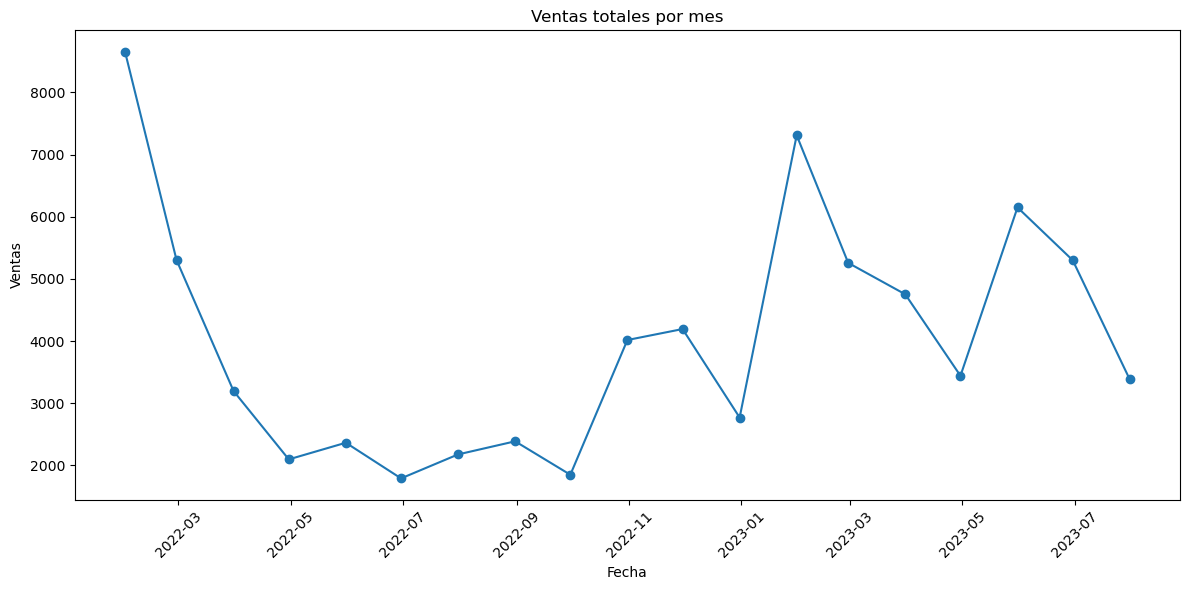

In [10]:
#EDA-Visión global agrupada por fecha
# Agrupar por mes
df_time = df.set_index('DATE').resample('M')['TOTAL_VALUE_SALES'].sum().reset_index()

# Visualización
plt.figure(figsize=(12,6))
plt.plot(df_time['DATE'], df_time['TOTAL_VALUE_SALES'], marker='o')
plt.title("Ventas totales por mes")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

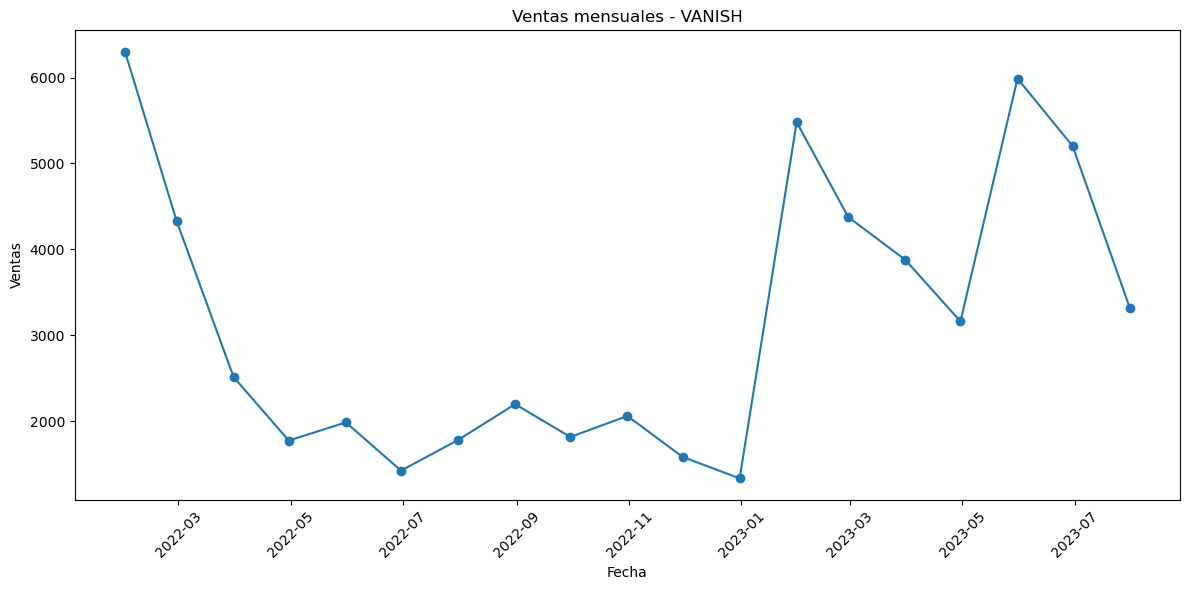

In [11]:
#EDA-Serie filtrada por Brand del producto
producto = df[df['BRAND'].str.contains("VANISH", case=False)]

#Agrupar por mes
producto_time = producto.set_index('DATE').resample('M')['TOTAL_VALUE_SALES'].sum().reset_index()

#Visualización
plt.figure(figsize=(12,6))
plt.plot(producto_time['DATE'], producto_time['TOTAL_VALUE_SALES'], marker='o')
plt.title("Ventas mensuales - VANISH")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

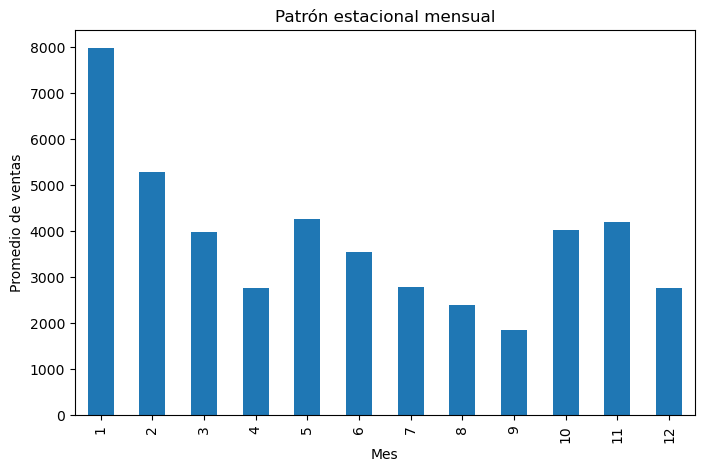

In [12]:
#EDA-Identificar si existe estacionalidad mensual visible
df_time['MONTH'] = df_time['DATE'].dt.month

# Promedio por mes
monthly_pattern = df_time.groupby('MONTH')['TOTAL_VALUE_SALES'].mean()

# Visualización
plt.figure(figsize=(8,5))
monthly_pattern.plot(kind='bar')
plt.title("Patrón estacional mensual")
plt.xlabel("Mes")
plt.ylabel("Promedio de ventas")
plt.show()

In [13]:
#Selección de técnica de modelado
print("""
Se selecciona un modelo SARIMA debido a que la serie presenta componentes de tendencia y estacionalidad anual. 
La presencia de variaciones periódicas en los meses y un crecimiento interanual significativo indica que un modelo 
de regresión simple no capturaría adecuadamente la dependencia temporal ni los patrones cíclicos. 
Por lo tanto, SARIMA permite modelar tanto la estructura autorregresiva como la estacionalidad observada en los datos.
""")


Se selecciona un modelo SARIMA debido a que la serie presenta componentes de tendencia y estacionalidad anual. 
La presencia de variaciones periódicas en los meses y un crecimiento interanual significativo indica que un modelo 
de regresión simple no capturaría adecuadamente la dependencia temporal ni los patrones cíclicos. 
Por lo tanto, SARIMA permite modelar tanto la estructura autorregresiva como la estacionalidad observada en los datos.



In [14]:
#División de datos para entrenamiento-prueba
# Agregar ventas por fecha
df_time = df.groupby('DATE')['TOTAL_VALUE_SALES'].sum().reset_index()

# Convertir a datetime
df_time['DATE'] = pd.to_datetime(df_time['DATE'])

# Ordenar
df_time = df_time.sort_values('DATE')

# Establecer índice
df_time.set_index('DATE', inplace=True)

# División 80/20
train_size = int(len(df_time) * 0.8)

train = df_time.iloc[:train_size]
test = df_time.iloc[train_size:]

print("Train:", train.shape)
print("Test:", test.shape)

Train: (64, 1)
Test: (16, 1)


In [15]:
#Modelo SARIMA inicial
model = SARIMAX(
    train['TOTAL_VALUE_SALES'],
    order=(1,1,1),              # (p,d,q)
    seasonal_order=(1,1,1,12)   # (P,D,Q,s)
)

results = model.fit()

# Resumen del modelo
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                  TOTAL_VALUE_SALES   No. Observations:                   64
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -361.140
Date:                            Tue, 24 Mar 2026   AIC                            732.280
Time:                                    13:51:14   BIC                            741.940
Sample:                                         0   HQIC                           735.972
                                             - 64                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5724      0.514      1.114      0.265      -0.435       1.580
ma.L1         -0.7353      0.510   

In [16]:
#Validación del modelo
#Predicción usando índices numéricos
start = len(train)
end = len(train) + len(test) - 1

predictions = results.predict(start=start, end=end)

#Alinear índice con test
predictions.index = test.index

In [17]:
#Calcular métricas
mse = mean_squared_error(test['TOTAL_VALUE_SALES'], predictions)
mae = mean_absolute_error(test['TOTAL_VALUE_SALES'], predictions)

#MAPE
mape = np.mean(np.abs((test['TOTAL_VALUE_SALES'] - predictions) / test['TOTAL_VALUE_SALES'])) * 100

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}%")

MSE: 933656.0132093686
MAE: 840.3458470944008
MAPE: 83.65139781457421%


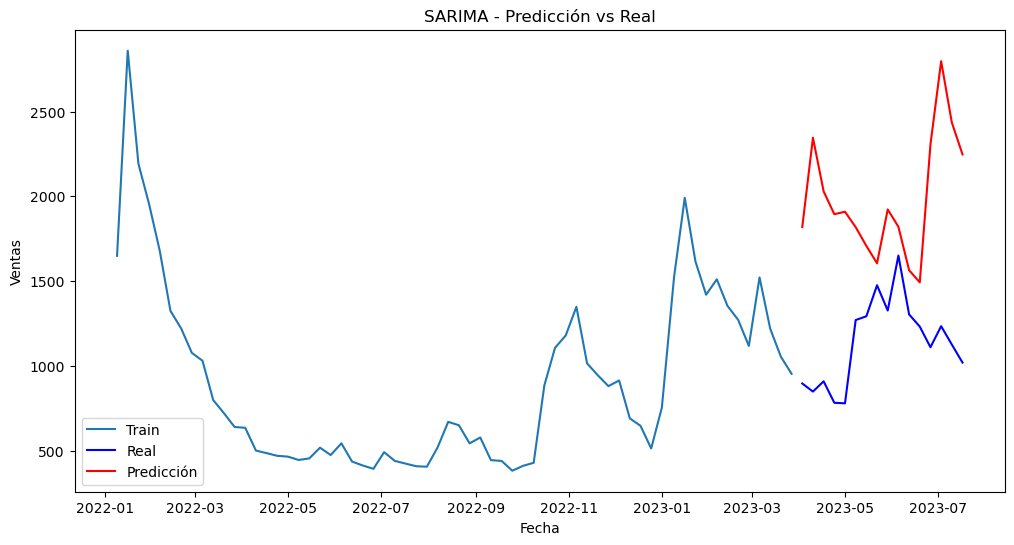

In [19]:
#Visualización de resultados
plt.figure(figsize=(12,6))

plt.plot(train.index, train['TOTAL_VALUE_SALES'], label='Train')
plt.plot(test.index, test['TOTAL_VALUE_SALES'], label='Real', color='blue')
plt.plot(predictions.index, predictions, label='Predicción', color='red')

plt.legend()
plt.title("SARIMA - Predicción vs Real")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()

In [20]:
#Conclusiones del modelo
print("""
Métricas obtenidas:
-MSE: 933656.0132093686
-MAE: 840.3458470944008
-MAPE: 83.65139781457421%

Conclusión técnica:
El modelo SARIMA inicial presenta un desempeño limitado, por métricas de error elevadas, 
lo que indica una baja capacidad predictiva. La parametrización utilizada (1,1,1)(1,1,1,12) no logra 
capturar adecuadamente la dinámica de la serie temporal.

Decisión:
Se decide realizar un proceso de optimización con el objetivo de mejorar 
el ajuste del modelo y su capacidad de generalización en futuras predicciones.
""")


Métricas obtenidas:
-MSE: 933656.0132093686
-MAE: 840.3458470944008
-MAPE: 83.65139781457421%

Conclusión técnica:
El modelo SARIMA inicial presenta un desempeño limitado, por métricas de error elevadas, 
lo que indica una baja capacidad predictiva. La parametrización utilizada (1,1,1)(1,1,1,12) no logra 
capturar adecuadamente la dinámica de la serie temporal.

Decisión:
Se decide realizar un proceso de optimización con el objetivo de mejorar 
el ajuste del modelo y su capacidad de generalización en futuras predicciones.



In [22]:
#Ajuste y optimización del modelo
import itertools

# Rangos de parámetros
p = d = q = range(0, 3)
P = D = Q = range(0, 2)

# Combinaciones
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in itertools.product(P, D, Q)]

best_aic = float("inf")
best_params = None
best_seasonal = None

# Búsqueda
for param in pdq:
    for seasonal_param in seasonal_pdq:
        try:
            model = SARIMAX(
                train['TOTAL_VALUE_SALES'],
                order=param,
                seasonal_order=seasonal_param,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            
            results = model.fit(disp=False)
            
            if results.aic < best_aic:
                best_aic = results.aic
                best_params = param
                best_seasonal = seasonal_param
                
        except:
            continue

print("Mejores parámetros:")
print("ARIMA:", best_params)
print("SARIMA:", best_seasonal)
print("AIC:", best_aic)

Mejores parámetros:
ARIMA: (0, 2, 2)
SARIMA: (1, 1, 1, 12)
AIC: 488.52068836936957


In [23]:
#Entrenamiento
model_opt = SARIMAX(
    train['TOTAL_VALUE_SALES'],
    order=best_params,
    seasonal_order=best_seasonal
)

results_opt = model_opt.fit()

In [24]:
#Predicción
start = len(train)
end = len(train) + len(test) - 1

pred_opt = results_opt.predict(start=start, end=end)
pred_opt.index = test.index

In [25]:
#Evaluación del modelo
mse_opt = mean_squared_error(test['TOTAL_VALUE_SALES'], pred_opt)
mae_opt = mean_absolute_error(test['TOTAL_VALUE_SALES'], pred_opt)
mape_opt = np.mean(np.abs((test['TOTAL_VALUE_SALES'] - pred_opt) / test['TOTAL_VALUE_SALES'])) * 100

print(f"MSE: {mse_opt}")
print(f"MAE: {mae_opt}")
print(f"MAPE: {mape_opt}%")

MSE: 1033828.1686280796
MAE: 874.2918936486207
MAPE: 86.29309395290119%


In [27]:
#Conclusiones del modelo
print("""
Aunque se intentó mejorar el modelo SARIMA, los resultados siguen siendo poco precisos (MAPE mayor al 80%).
Esto indica que el modelo no logra adaptarse bien a los datos. 
Probablemente se debe a que las ventas son muy variables, no hay suficiente historial para identificar 
patrones claros y además se están combinando distintos productos que se comportan de manera diferente.
      
Se toma la desición de cambiar el enfoque del modelo
""")


Aunque se intentó mejorar el modelo SARIMA, los resultados siguen siendo poco precisos (MAPE mayor al 80%).
Esto indica que el modelo no logra adaptarse bien a los datos. 
Probablemente se debe a que las ventas son muy variables, no hay suficiente historial para identificar 
patrones claros y además se están combinando distintos productos que se comportan de manera diferente.
      
Se toma la desición de cambiar el enfoque del modelo



In [28]:
#Preparación del dataset para el modelo
#Copia del dataset
df_model = df.copy()

#Asegurar formato fecha
df_model['DATE'] = pd.to_datetime(df_model['DATE'])

#Feature Engineering temporal
df_model['YEAR'] = df_model['DATE'].dt.year
df_model['MONTH'] = df_model['DATE'].dt.month
df_model['WEEK'] = df_model['DATE'].dt.isocalendar().week.astype(int)
df_model['DAY'] = df_model['DATE'].dt.day

#Agregar por fecha (nivel de análisis)
df_model = df_model.groupby('DATE').agg({
    'TOTAL_VALUE_SALES': 'sum',
    'YEAR': 'first',
    'MONTH': 'first',
    'WEEK': 'first',
    'DAY': 'first'
}).reset_index()

df_model.head()

,DATE,TOTAL_VALUE_SALES,YEAR,MONTH,WEEK,DAY
0,2022-01-09,1649.798,2022,1,1,9
1,2022-01-16,2858.308,2022,1,2,16
2,2022-01-23,2192.402,2022,1,3,23
3,2022-01-30,1954.273,2022,1,4,30
4,2022-02-06,1678.188,2022,2,5,6


In [29]:
#Definición de variables
#Variable objetivo
y = df_model['TOTAL_VALUE_SALES']

#Variables independientes
X = df_model[['YEAR', 'MONTH', 'WEEK', 'DAY']]

In [30]:
#División temporal
# División 80/20
train_size = int(len(df_model) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [31]:
#Modelo de regresión
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

In [32]:
#Predicción
y_pred = model_lr.predict(X_test)

In [33]:
#Evaluación
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}%")

MSE: 79649.40822746922
MAE: 232.14311470125395
MAPE: 22.573522364869746%


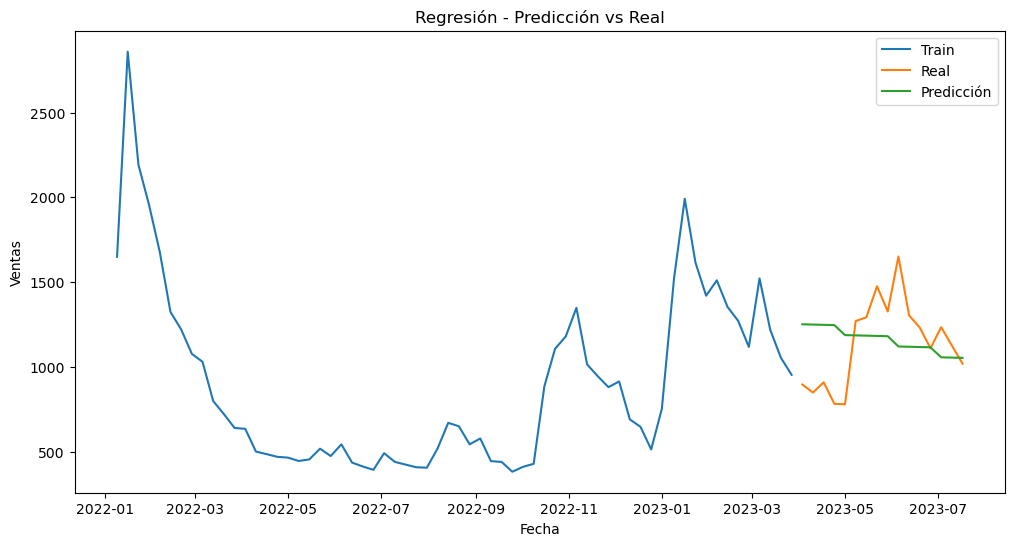

In [34]:
#Visualización
plt.figure(figsize=(12,6))

plt.plot(df_model['DATE'][:train_size], y_train, label='Train')
plt.plot(df_model['DATE'][train_size:], y_test, label='Real')
plt.plot(df_model['DATE'][train_size:], y_pred, label='Predicción')

plt.legend()
plt.title("Regresión - Predicción vs Real")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()

In [36]:
#Conclusiones del ajuste del nuevo modelo
print("""
MSE: 79649.40822746922
MAE: 232.14311470125395
MAPE: 22.573522364869746%

El modelo de regresión lineal mostró un mejor desempeño que los modelos de series de tiempo evaluados,
alcanzando un MAPE del 22.57%. 
Esto indica una capacidad razonable para capturar la tendencia general de las ventas,
aunque con limitaciones en la predicción de fluctuaciones abruptas.
Dado el tamaño limitado de la serie temporal y la alta variabilidad de los datos,
el enfoque de regresión resultó más adecuado y estable para el proyecto.
""")


MSE: 79649.40822746922
MAE: 232.14311470125395
MAPE: 22.573522364869746%

El modelo de regresión lineal mostró un mejor desempeño que los modelos de series de tiempo evaluados,
alcanzando un MAPE del 22.57%. 
Esto indica una capacidad razonable para capturar la tendencia general de las ventas,
aunque con limitaciones en la predicción de fluctuaciones abruptas.
Dado el tamaño limitado de la serie temporal y la alta variabilidad de los datos,
el enfoque de regresión resultó más adecuado y estable para el proyecto.



In [37]:
#Predicción futura
#Crear fechas futuras (ej. 8 semanas)
future_dates = pd.date_range(start=df_model['DATE'].max(), periods=9, freq='W')[1:]

df_future = pd.DataFrame({'DATE': future_dates})

#Crear features
df_future['YEAR'] = df_future['DATE'].dt.year
df_future['MONTH'] = df_future['DATE'].dt.month
df_future['WEEK'] = df_future['DATE'].dt.isocalendar().week.astype(int)
df_future['DAY'] = df_future['DATE'].dt.day

In [38]:
#Predicción futura con modelo lineal
future_pred = model_lr.predict(df_future[['YEAR','MONTH','WEEK','DAY']])

df_future['PREDICTION'] = future_pred

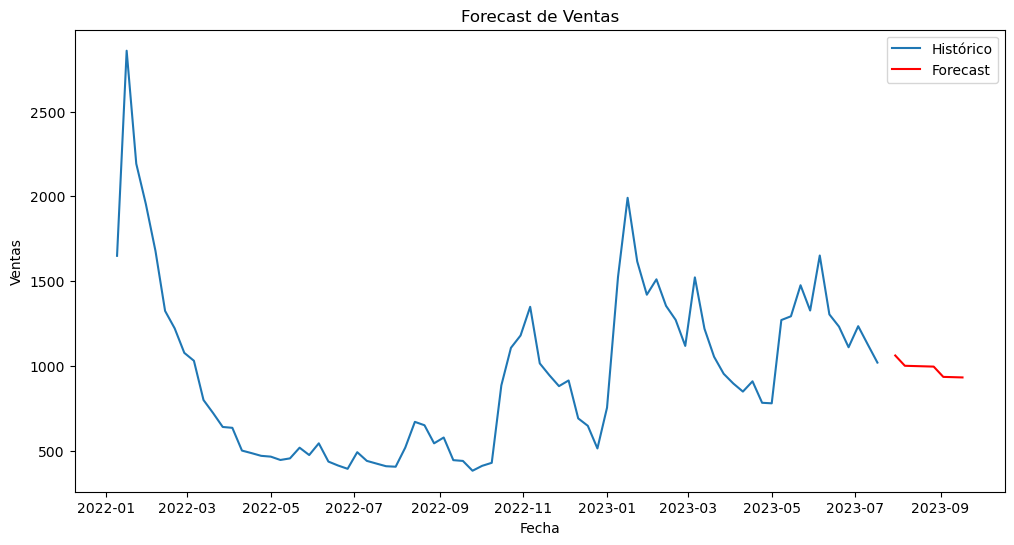

In [39]:
#Visualización
plt.figure(figsize=(12,6))

plt.plot(df_model['DATE'], df_model['TOTAL_VALUE_SALES'], label='Histórico')
plt.plot(df_future['DATE'], df_future['PREDICTION'], label='Forecast', color='red')

plt.legend()
plt.title("Forecast de Ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()

In [40]:
#Conclusiones finales
print("""
-Lectura de la gráfica:
      Existe una alta volatilidad y un pico muy fuerte en inicios de 2022
      Existió una caída pronunciada aunque también una recuperación en 2023
      Aúnque se identifica crecimiento en los meses cercanos a inicio/fin de año no se pudo establecer un patrón
      La predicción resultó en una disminución/estabilización de los datos
-Conclusiones basadas en el modelo:
      Aún con la fluctuación se puede esperar una disminución/estabilización de las ventas
      No se esperan crecimiento o decrecimiento crítico
      Se puede buscar un ajuste operativo cercano al rango de estabilización
      Este modelo no incorpora variables externas que pueden influir, como lo puede ser el marketing
      Tanto en conclusiones previas como actuales se nota la predominancia del producto VANISH
-Recomendaciones:
      Planeación de inventario para mantener un stock según el pronostico y evitar el sobreinventario
      Los datos de ventas no visualizan un crecimiento próximo, para una búsqueda de crecimiento pueden inferir otros factores externos
      El modelo puede presentar una línea base que puede ser referencia operativa pero no como predicción de fluctuaciones abruptas
""")


-Lectura de la gráfica:
      Existe una alta volatilidad y un pico muy fuerte en inicios de 2022
      Existió una caída pronunciada aunque también una recuperación en 2023
      Aúnque se identifica crecimiento en los meses cercanos a inicio/fin de año no se pudo establecer un patrón
      La predicción resultó en una disminución/estabilización de los datos
-Conclusiones basadas en el modelo:
      Aún con la fluctuación se puede esperar una disminución/estabilización de las ventas
      No se esperan crecimiento o decrecimiento crítico
      Se puede buscar un ajuste operativo cercano al rango de estabilización
      Este modelo no incorpora variables externas que pueden influir, como lo puede ser el marketing
      Tanto en conclusiones previas como actuales se nota la predominancia del producto VANISH
-Recomendaciones:
      Planeación de inventario para mantener un stock según el pronostico y evitar el sobreinventario
      Los datos de ventas no visualizan un crecimiento próxim